## Анализ зависимости суммы операции и типа операции

In [2]:
import pyspark
from pyspark.ml import Transformer, Pipeline
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql.functions import first, sum, col, max, min,avg
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, desc

In [3]:
# создание spark-сессии
spark =SparkSession.builder \
    .appName("analysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "1g") \
    .getOrCreate()

## ANALYTICS POSTPROCESS

In [10]:
train_path = ["../datasets/train/train_part_1.parquet","../datasets/train/train_part_2.parquet","../datasets/train/train_part_3.parquet"]
# train_path = ["../datasets/joined/train_data.parquet","../datasets/joined/valid_data.parquet"]

df_train = spark.read.parquet(*train_path)

df_labels = spark.read.parquet('../datasets/train/train_labels.parquet')
df_train = df_train.join(df_labels, on = 'event_id',how='left').fillna(0,subset=['target'])

## столбики

In [ ]:
df_train.dtypes

In [ ]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").sample(False, 0.1).toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение сумм операций (логарифмическая шкала)")
plt.show()

## ИЩЕМ ФРОД

In [ ]:
# 1. Берем 10% данных без повторений
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select("operaton_amt").filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="operaton_amt", kde=True, log_scale=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## РАСПРЕДЕЛЕНИЕ ФРОДОВ ПЕРЕВОДОВ В ЗАВИСИМОСТИ ОТ ТИПА ОПЕРАЦИИ

In [ ]:
# Это безопасно для памяти, если общий объем данных велик
pdf = df_train.select('event_type_nm').filter('target == 1').toPandas()

# 2. Строим гистограмму
plt.figure(figsize=(12, 6))
# Параметр log_scale=True решит проблему визуализации
sns.histplot(data=pdf, x="event_type_nm", kde=True, color="skyblue")
plt.title("Распределение ФРОДО (логарифмическая шкала)")
plt.show()

## ВСЕГДА ЛИ ФРОД В ВЗЛОМАННЫХ УСТРОЙСТВАХ?

In [ ]:
# Подготовка данных
pdf1 = df_train.filter('target == 1').select('compromised').toPandas()
# Для target=0 берем выборку, чтобы не перегрузить память
pdf2 = df_train.filter('target == 0').select('compromised').sample(False, 0.1).toPandas()

plt.figure(figsize=(12, 6))

# Рисуем оба распределения на одних осях
# stat="density" нормализует площади графиков, чтобы их можно было сравнить при разном кол-ве строк
sns.histplot(data=pdf1, x="compromised", kde=True, color="red", label="Фрод (Target 1)", stat="density", common_norm=False)
sns.histplot(data=pdf2, x="compromised", kde=True, color="skyblue", label="Норма (Target 0)", stat="density", common_norm=False)

plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
# Добавьте это, если данные сильно разбросаны:
# plt.xscale('log') 

plt.show()


## РАСПРЕДЕЛЕНИЕ СТОИМОСТИ ОПЕРАЦИЙ В ЗАВИСИМОСТИ ОТ ТИПА ОПИСАНИЯ ОПЕРАЦИИ

In [ ]:
# Подготовка данных
pdf1 = df_train.filter('target == 1 AND operaton_amt>0').select('event_type_nm','operaton_amt').toPandas()
# Для target=0 берем выборку, чтобы не перегрузить память
pdf2 = df_train.filter('target == 0 AND operaton_amt>0' ).select('event_type_nm','operaton_amt').sample(False, 0.1).toPandas()

plt.figure(figsize=(12, 6))

# Рисуем оба распределения на одних осях
# stat="density" нормализует площади графиков, чтобы их можно было сравнить при разном кол-ве строк
sns.boxplot(data=pdf1, x="operaton_amt", palette='dark:red', label="Фрод (Target 1)", log_scale=True, hue='event_type_nm')
plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf2, x="operaton_amt", palette='dark:blue', label="Норма (Target 0)",log_scale=True, hue='event_type_nm')
plt.legend()
plt.title("Сравнение распределения compromised для фрода и нормы")
plt.show()


In [ ]:
value = df_train.filter('target == 1').select('customer_id').distinct().count()
print(f"Кол-во клиентов подвершся фроду: {value}")

In [ ]:

fraud_rating = (
    df_train
    .filter('target == 1') # Оставляем только фрод
    .groupBy('customer_id') # Группируем по пользователям
    .agg(F.count('target').alias('fraud_count')) # Считаем количество
    .orderBy(F.col('fraud_count').desc()) # Сортируем: самые активные сверху
)

fraud_rating.show(10)

In [ ]:
df_train.select('pos_cd').distinct().count()

## POSTPREPROCESS

In [ ]:
df_train.printSchema()

In [ ]:
df_train.select('compromised').distinct().show()

In [ ]:
df_train.select('compromised').groupBy('compromised').count().show()

## web_rdp_connection

In [ ]:
df_train.select('web_rdp_connection').distinct().show()

In [ ]:
df_train.select('web_rdp_connection').groupBy('web_rdp_connection').count().show()

## phone_voip_call_state

In [ ]:
df_train.select('phone_voip_call_state').distinct().show()

In [ ]:
df_train.select('phone_voip_call_state').groupBy('phone_voip_call_state').count().show()

## developer_tools

In [ ]:
df_train.select('developer_tools').distinct().show()

In [ ]:
df_train.select('developer_tools').groupBy('developer_tools').count().show()

## screen_size

In [ ]:
# df_train.select('screen_size').distinct().show()

In [ ]:
# df_train.select('screen_size').distinct().count()

In [ ]:
# df_train.select('screen_size').groupBy('screen_size').count().show(50)

## device_system_version

In [ ]:
df_train.select('device_system_version').groupBy('device_system_version').count().sort('count',ascending = False).show(50)

In [ ]:
df_train.select('device_system_version','target').groupBy('target','device_system_version').count().sort('count',ascending=False).show(50)

In [ ]:
pdf = df_train.select('device_system_version', 'target') \
    .groupBy('device_system_version', 'target') \
    .count() \
    .toPandas()


# 2. Сортировка (выберите нужный вариант):

# Вариант А: Сортировка по названию версии (по оси X)
pdf = pdf.sort_values('device_system_version')

# Вариант Б: Сортировка по популярности (где больше всего данных — слева)
# Сначала считаем общий count для каждой версии
# order = pdf.groupby('device_system_version')['count'].sum().sort_values(ascending=False).index

# 3. Визуализация
plt.figure(figsize=(20, 6))
sns.barplot(data=pdf, x='device_system_version', y='count', hue='target') #, order=order)

plt.title('Распределение таргета по версиям систем (отсортировано)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_train = df_train.withColumn(
    'device_system_version', 
    F.regexp_extract(F.col('device_system_version'), r'(\d+)', 1).cast('int')
)
df_train =df_train.fillna(-1, subset=["device_system_version"]) \
       .withColumn("device_system_version", col("device_system_version").cast("byte"))

In [ ]:
pdf = df_train.select('device_system_version', 'target') \
    .groupBy('device_system_version', 'target') \
    .count() \
    .toPandas()


# 2. Сортировка (выберите нужный вариант):

# Вариант А: Сортировка по названию версии (по оси X)
pdf = pdf.sort_values('device_system_version')

# Вариант Б: Сортировка по популярности (где больше всего данных — слева)
# Сначала считаем общий count для каждой версии
# order = pdf.groupby('device_system_version')['count'].sum().sort_values(ascending=False).index

# 3. Визуализация
plt.figure(figsize=(20, 6))
sns.barplot(data=pdf, x='device_system_version', y='count', hue='target') #, order=order)

plt.title('Распределение таргета по версиям систем (отсортировано)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## battery

In [ ]:
df_train.select('battery').distinct().show()

In [ ]:
df_train.select('battery').groupBy('battery').count().show(50)

## operating_system_type

In [ ]:
df_train.select('operating_system_type','target').groupBy('target','operating_system_type').count().show(50)

In [ ]:
df_train = df_train.withColumn(
    'os_category',
    F.when(F.col('operating_system_type') == 6.0, 0)
     .when(F.col('operating_system_type') == 4.0, 1)
     .when(F.col('operating_system_type').isin([7.0, 9.0]), 2)
     .when(F.col('operating_system_type') == -1, -1) # Явно сохраняем -1
     .when(F.col('operating_system_type').isNull(), -1) # Обрабатываем null, если нужно
     .otherwise(3)
     .cast('byte')
)

In [ ]:
df_train.select('os_category','target').groupBy('target','os_category').count().show(50)

## timezone

In [ ]:
df_train.select('timezone').distinct().count()

In [ ]:
df_train = df_train.withColumn(
    'tz_category',
    F.when(F.col('timezone') == -1, -1)                      # Сохраняем спецзначение
     .when(F.col('timezone') == 31, 0)                     # Условие для 0
     .when(F.col('timezone').isin([13, 21, 27, 16, 33, 20]), 1) # Группа 1
     .otherwise(2)                                           # Все остальные -> 2
     .cast('byte')                                           # Эквивалент int8
)

In [ ]:
df_train.select('tz_category').groupBy('tz_category').count().show(50)

## browser_language

In [ ]:
df_train.select('browser_language').distinct().count()


In [ ]:
df_train.select('browser_language').distinct().show()

In [ ]:
df_train.select('browser_language') \
    .groupBy('browser_language') \
    .count() \
    .orderBy(desc("count")) \
    .show(50)

## accept_language

In [ ]:
lang = df_train.select('accept_language').distinct()
print(lang,sep='\n')

In [ ]:
df_train.select('accept_language') \
    .groupBy('accept_language') \
    .count() \
    .orderBy(desc("accept_language")) \
    .show(100)

In [ ]:
df_train = df_train.withColumn(
    'language_category',
    F.when(F.col('accept_language').isNull(), -1)
     .when(F.lower(F.col('accept_language')) == 'ru', 0)
     .when(F.lower(F.col('accept_language')) == 'ru-ru', 1)
     # Проверяем наличие 'en' И 'ru' в строке (аналог 'en' in val and 'ru' in val)
     .when(F.lower(F.col('accept_language')).contains('en') & 
           F.lower(F.col('accept_language')).contains('ru'), 2)
     .otherwise(3)
     .cast('byte')
)

In [ ]:
pdf = df_train.select('accept_language', 'target') \
    .groupBy('accept_language', 'target') \
    .count() \
    .toPandas()


# 2. Сортировка (выберите нужный вариант):

# Вариант А: Сортировка по названию версии (по оси X)
pdf = pdf.sort_values('accept_language')

# 3. Визуализация
plt.figure(figsize=(20, 6))
sns.barplot(data=pdf, x='accept_language', y='count', hue='target') #, order=order)

plt.title('Распределение таргета по версиям языку системы (отсортировано)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
pdf = df_train.select('language_category', 'target') \
    .groupBy('language_category', 'target') \
    .count() \
    .toPandas()


# 2. Сортировка (выберите нужный вариант):

# Вариант А: Сортировка по названию версии (по оси X)
pdf = pdf.sort_values('language_category')

# 3. Визуализация
plt.figure(figsize=(20, 6))
sns.barplot(data=pdf, x='language_category', y='count', hue='target') #, order=order)

plt.title('Распределение таргета по версиям языку системы (отсортировано)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## pos_cd

In [5]:
df_train.select('pos_cd').distinct().show()

+------+
|pos_cd|
+------+
|    14|
|     9|
|    10|
|     4|
|     3|
|     1|
|     8|
|    12|
|    16|
|    17|
|     0|
|    11|
|     5|
|     2|
|  NULL|
+------+



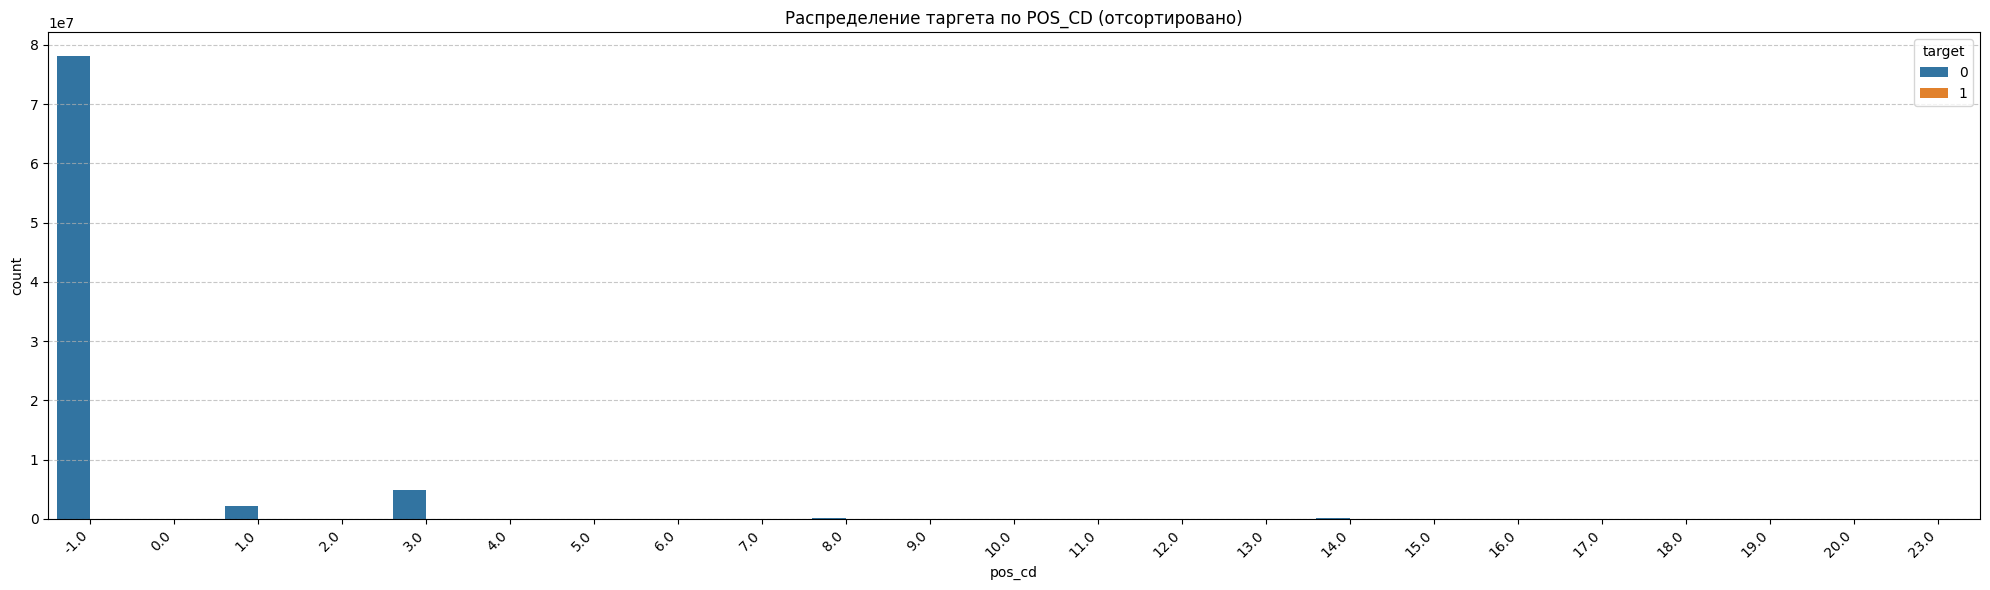

In [13]:
pdf = df_train.select('pos_cd', 'target') \
    .groupBy('pos_cd', 'target') \
    .count() \
    .toPandas()


# 2. Сортировка (выберите нужный вариант):

# Вариант А: Сортировка по названию версии (по оси X)
pdf = pdf.sort_values('pos_cd').fillna(-1)

# 3. Визуализация
plt.figure(figsize=(20, 6))
sns.barplot(data=pdf, x='pos_cd', y='count', hue='target') #, order=order)

plt.title('Распределение таргета по POS_CD (отсортировано)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_train.select('pos_cd').distinct().count()

## mcc_code

In [ ]:
df_train.select('mcc_code').distinct().show()

In [ ]:
df_train.select('mcc_code').distinct().count()